In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

In [3]:
# Load data
df = pd.read_csv("../data/churn.csv")

In [4]:
# Quick confirmation
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# check data types
print(df.dtypes)


customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [6]:
# missing values check
print(df.isnull().sum())


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [7]:
# summary statistics
print(df.describe())


       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [8]:
# Convert TotalCharges from string to number
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# NOW check missing values
print(f"Missing values in TotalCharges after conversion: {df['TotalCharges'].isnull().sum()}")
print(f"Total rows before dropping: {len(df)}")

# Drop the rows where conversion failed (these are empty strings)
df = df.dropna(subset=['TotalCharges'])

print(f"Total rows after dropping: {len(df)}")
print(f"Rows removed: {7043 - len(df)}")

Missing values in TotalCharges after conversion: 11
Total rows before dropping: 7043
Total rows after dropping: 7032
Rows removed: 11


Churn Distribution
Churn: 1869 customers (26.6%)
No Churn: 5163 customers (73.4%)


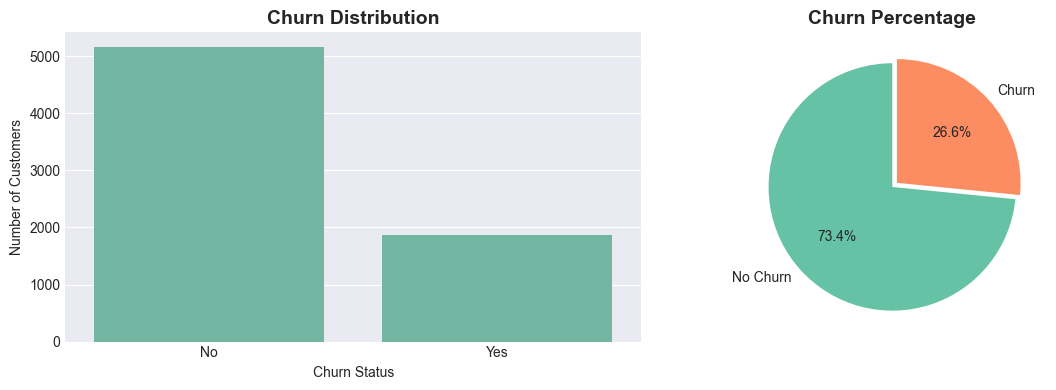

In [9]:
# Check churn distribution
print("Churn Distribution")
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(f"Churn: {churn_counts['Yes']} customers ({churn_pct['Yes']:.1f}%)")
print(f"No Churn: {churn_counts['No']} customers ({churn_pct['No']:.1f}%)")

# Visualize
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='Churn', ax=axes[0])
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn Status')
axes[0].set_ylabel('Number of Customers')

axes[1].pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%', 
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Churn Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

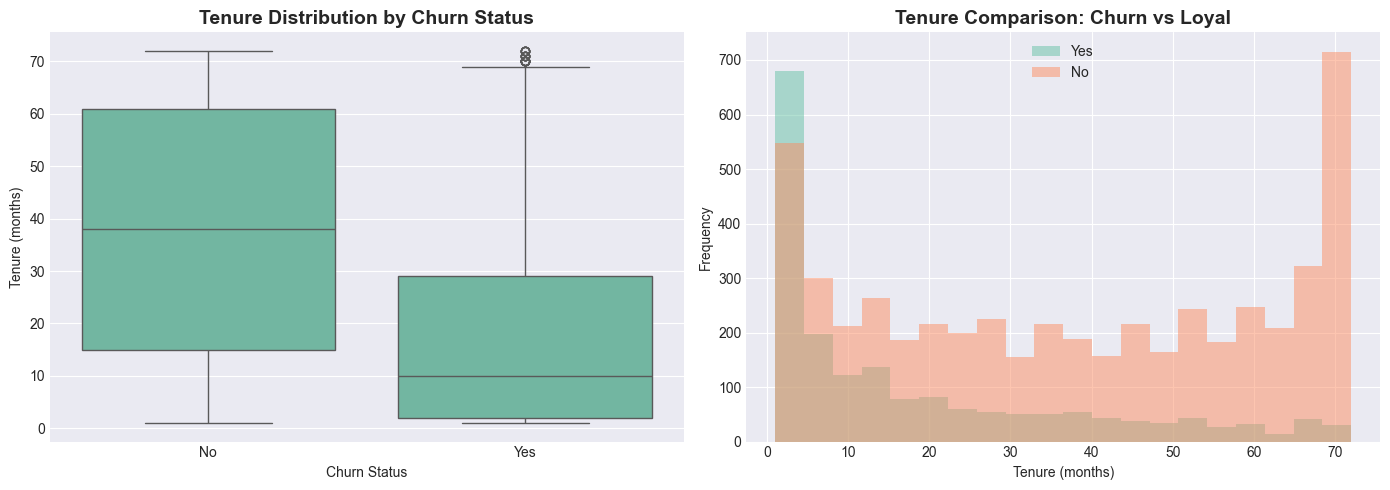

Statistics
Churned customers: 18.0 months average
Loyal customers: 37.7 months average
Difference: 19.7 months
→ Churned customers leave 109% earlier


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0])
axes[0].set_title('Tenure Distribution by Churn Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn Status')
axes[0].set_ylabel('Tenure (months)')

# Overlapping histograms
for churn_status in ['Yes', 'No']:
    subset = df[df['Churn'] == churn_status]
    axes[1].hist(subset['tenure'], alpha=0.5, label=f'{churn_status}', bins=20)
axes[1].set_title('Tenure Comparison: Churn vs Loyal', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

# Calculate statistics
churn_tenure = df[df['Churn']=='Yes']['tenure'].mean()
loyal_tenure = df[df['Churn']=='No']['tenure'].mean()

print(f"Statistics")
print(f"Churned customers: {churn_tenure:.1f} months average")
print(f"Loyal customers: {loyal_tenure:.1f} months average")
print(f"Difference: {loyal_tenure - churn_tenure:.1f} months")
print(f"→ Churned customers leave {((loyal_tenure - churn_tenure)/churn_tenure*100):.0f}% earlier")

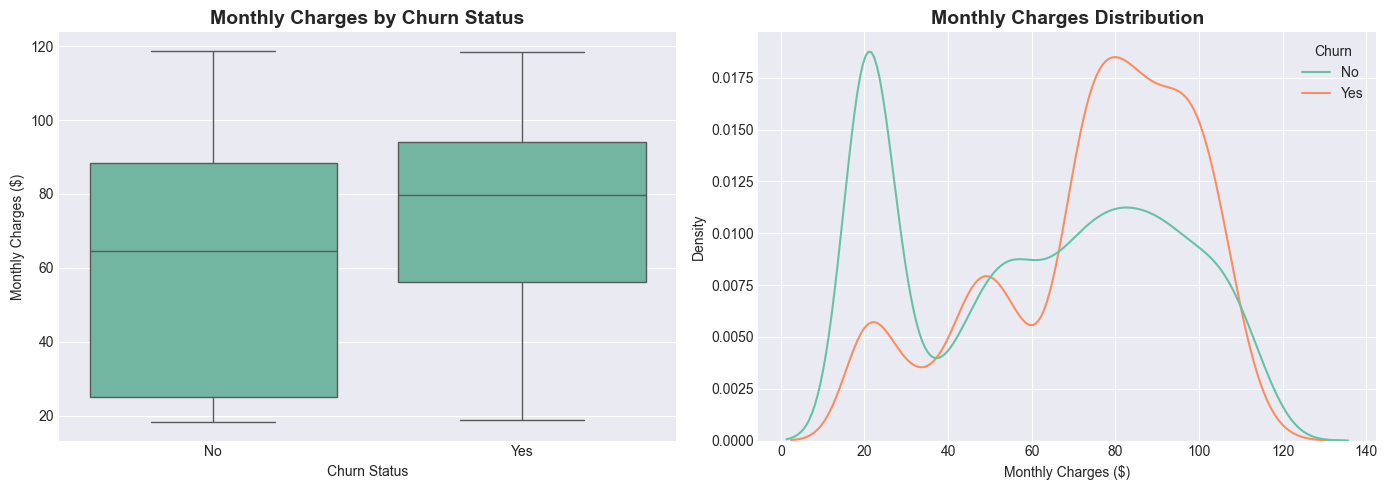

Statistics:
Churned customers: $74/month average
Loyal customers: $61/month average
Difference: $13/month higher for churners


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[0])
axes[0].set_title('Monthly Charges by Churn Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn Status')
axes[0].set_ylabel('Monthly Charges ($)')

# Density plot
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', common_norm=False, ax=axes[1])
axes[1].set_title('Monthly Charges Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

churn_monthly = df[df['Churn']=='Yes']['MonthlyCharges'].mean()
loyal_monthly = df[df['Churn']=='No']['MonthlyCharges'].mean()

print(f"Statistics:")
print(f"Churned customers: ${churn_monthly:.0f}/month average")
print(f"Loyal customers: ${loyal_monthly:.0f}/month average")
print(f"Difference: ${churn_monthly - loyal_monthly:.0f}/month higher for churners")

Churn Rate by Contract Type
Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8




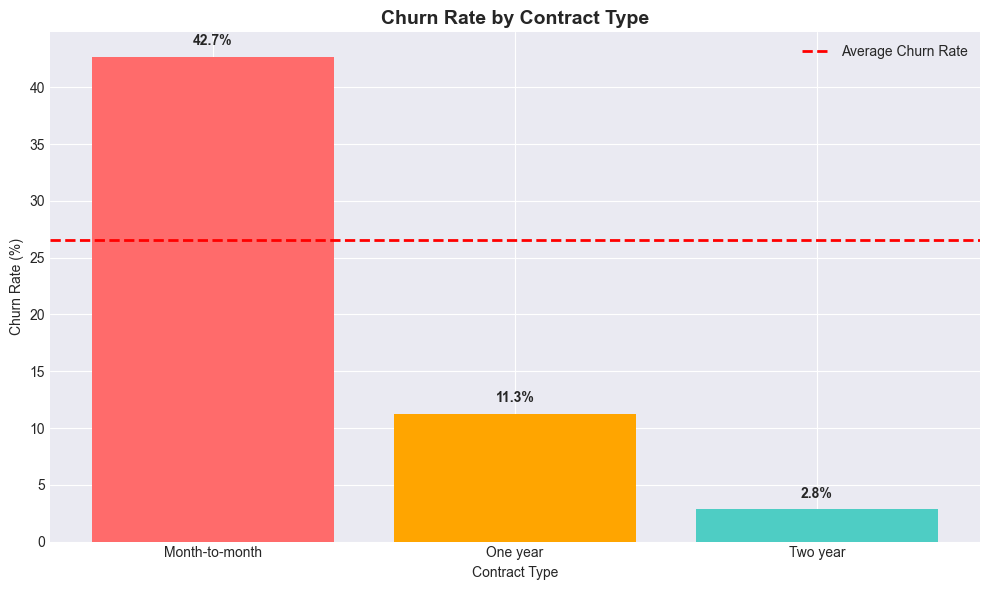

KEY INSIGHT:
Month-to-month churn: 42.7%
Two year contract churn: 2.8%
→ Month-to-month customers are 15x MORE likely to churn!


In [12]:
# Cross tabulation
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
print("Churn Rate by Contract Type")
print(contract_churn.round(1))
print("\n")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

# Create bar plot
contracts = contract_churn.index
churn_rates = contract_churn['Yes']
colors = ['#ff6b6b', '#ffa500', '#4ecdc4']

bars = ax.bar(contracts, churn_rates, color=colors)
ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Churn Rate (%)')
ax.axhline(y=df['Churn'].value_counts(normalize=True)['Yes']*100, 
           color='red', linestyle='--', linewidth=2, label='Average Churn Rate')

# Add percentage labels on bars
for bar, rate in zip(bars, churn_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{rate:.1f}%', ha='center', fontweight='bold')

ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Calculate risk multiplier
mtm_rate = contract_churn.loc['Month-to-month', 'Yes']
two_year_rate = contract_churn.loc['Two year', 'Yes']
multiplier = mtm_rate / two_year_rate

print(f"KEY INSIGHT:")
print(f"Month-to-month churn: {mtm_rate:.1f}%")
print(f"Two year contract churn: {two_year_rate:.1f}%")
print(f"→ Month-to-month customers are {multiplier:.0f}x MORE likely to churn!")

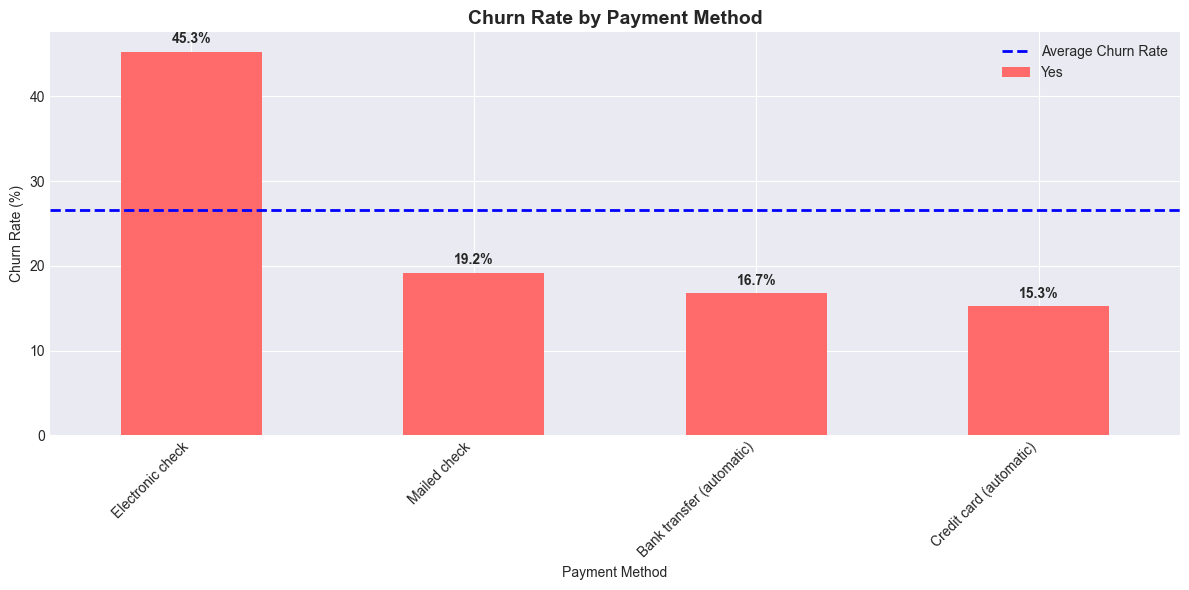


Payment Method Churn Rates:
Electronic check               45.3%
Mailed check                   19.2%
Bank transfer (automatic)      16.7%
Credit card (automatic)        15.3%


In [13]:
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(12, 6))
payment_sorted = payment_churn.sort_values('Yes', ascending=False)
payment_sorted['Yes'].plot(kind='bar', color='#ff6b6b', ax=ax)
ax.set_title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
ax.set_xlabel('Payment Method')
ax.set_ylabel('Churn Rate (%)')
ax.axhline(y=df['Churn'].value_counts(normalize=True)['Yes']*100, 
           color='blue', linestyle='--', linewidth=2, label='Average Churn Rate')

# Add labels
for i, (method, row) in enumerate(payment_sorted.iterrows()):
    ax.text(i, row['Yes'] + 1, f"{row['Yes']:.1f}%", ha='center', fontweight='bold')

ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nPayment Method Churn Rates:")
for method, row in payment_sorted.iterrows():
    print(f"{method:30} {row['Yes']:.1f}%")

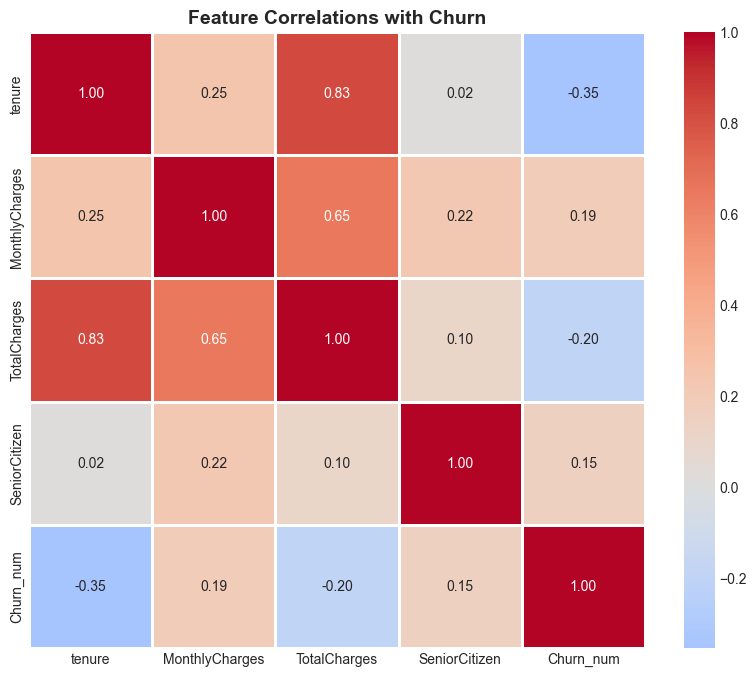


Strongest correlations with Churn:
MonthlyCharges       0.193
SeniorCitizen        0.151
TotalCharges         -0.199
tenure               -0.354


In [14]:
# Create numeric version for correlation
df_corr = df.copy()
df_corr['Churn_num'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

# Select numeric columns
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_num']
correlation_matrix = df_corr[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', linewidths=1)
plt.title('Feature Correlations with Churn', fontsize=14, fontweight='bold')
plt.show()

print("\nStrongest correlations with Churn:")
correlations = correlation_matrix['Churn_num'].sort_values(ascending=False)
for feature, corr in correlations.items():
    if feature != 'Churn_num':
        print(f"{feature:20} {corr:.3f}")